# IMDb Data Visualization

In this codebook, we will make a bar chart of all films in the IMDb dataset and group them by their Oscar nomination categories (No nomination, Nominee, Winner). The chart will measure every films IMDb user rating (1-10) against the total number of films in the dataset that were scored with that rating.

## Imports and helper functions

In [1]:
import pandas as pd
import plotly.express as px

%run helpers.ipynb

## Setting up data for distribution plotting
Create new column for Oscar nomination status

In [2]:
oscar_with_imdb, imdb_non_oscar = read_data('oscar_with_imdb.csv', 'imdb_non_oscar.csv')
oscar_with_imdb['Status'] = oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row == True else 'Nominated')
imdb_non_oscar['Status'] = 'No nomination'

Here we want to combine the two datasets and keep only the relevant columns to make this visualization.

Besides the obvious columns `title`, `rating`, and `Status`, `meta_score` (Metacritic score), and `votes` (number of user votes) are all important for adding additional context to for the visualization.

Metacritic is a website that aggregates reviews of films by critics and IMDb includes this score (0-100) for every film on its website. While this project investigates prestige bias, the Oscar awards are not the only way this bias can be highlighted. Thus, the inclusion of each films Metacritic score is included here in order to add another dimension to highlighting film quality against IMDb's userbase. The Metacritic score index can be broken down into the following categories:
- _Universal acclaim_ - 81 to 100
- _Generally favorable_ - 61 to 80
- _Mixed or average_ - 40 to 60
- _Genrally unfavorable_ - 20 to 39
- _Overwhelming dislike_ - 0 to 19

In [3]:
columns = ['title', 'rating', 'meta_score', 'votes', 'Status']
oscar_df = oscar_with_imdb[columns]
imdb_df = imdb_non_oscar[columns]

rating_graph_df = pd.concat([oscar_df, imdb_df], axis=0)

rating_graph_df

,title,rating,meta_score,votes,Status
0,The Noose,6.5,NaN,93.0,Nominated
1,The Patent Leather Kid,6.0,NaN,623.0,Nominated
2,The Last Command,7.9,NaN,4800.0,Winner
3,The Way of All Flesh,6.6,NaN,241.0,Winner
4,A Ship Comes In,5.5,NaN,246.0,Nominated
...,...,...,...,...,...
55679,The Toxic Avenger,6.0,66.0,554.0,No nomination
55680,The Astronaut,6.0,NaN,33.0,No nomination
55681,Popeye: The Slayer Man,3.8,NaN,425.0,No nomination
55682,Night of the Dead Sorority Babes,3.0,NaN,73.0,No nomination


The next step is to bin the IMDb rating awards from 1-10. This means that something like '1' on the x-axis of our visualization represents all user ratings 1.0 through 1.9. 

The dataset is then split up into groups by Oscar nomination and counts the number of films in each category by their rating bin. After that, we want to calculate each rating bin's average user vote and Metacritic score for each of the Oscar categories.

In [4]:
# bin the imdb ratings
bins = list(range(1, 11))
rating_graph_df['rating_bin'] = pd.cut(
    rating_graph_df['rating'],
    bins=bins,
    labels=range(1, 10),
    right=False, # bins should be [1, 2) (i.e rating 1 to 1.9)
    include_lowest=True # values like 1.0 won't be excluded
)

# group by counts for each imdb rating bin's oscar status
# add average user votes and metacritic score for each bin
rating_bin_counts = (
    rating_graph_df
    .groupby(['rating_bin', 'Status'])
    .agg(
        count=('title', 'count'),
        avg_votes=('votes', lambda x: round(x.mean(), 0)), # round to nearest whole number
        avg_meta_score=('meta_score', lambda x: round(x.mean(), 1)) # round to one decimal place
    )
    .reset_index()
)

rating_bin_counts['avg_meta_score'] = rating_bin_counts['avg_meta_score'].fillna('N/A')

We can see a clear picture of the breakdown for each rating bin. Based on the variance of the film count numbers, we will be log scaling the y-axis to account for this so that the visualization is normalized.

In [5]:
rating_bin_counts

,rating_bin,Status,count,avg_votes,avg_meta_score
0,1,No nomination,68,10178.0,30.6
1,2,No nomination,365,4329.0,20.6
2,3,No nomination,1628,2910.0,26.8
3,3,Nominated,2,501.0,N/A
4,4,No nomination,5535,3223.0,34.4
5,4,Nominated,25,23200.0,36.0
6,4,Winner,1,866.0,N/A
7,5,No nomination,14310,6614.0,44.7
8,5,Nominated,336,13032.0,55.7
9,5,Winner,26,48418.0,63.7


## Creating the bar chart for rating and vote counts
We plot the rating and vote counts along with tooltips for average user votes and average meta critic scores per film in each rating bucket.

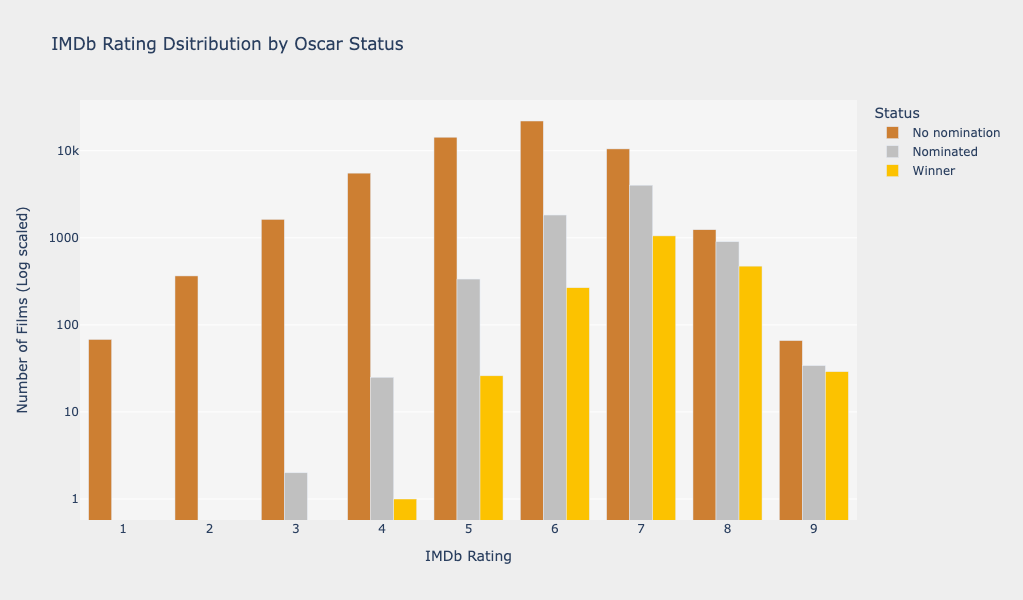

In [6]:
fig = px.bar(
    rating_bin_counts,
    x='rating_bin',
    y='count',
    color='Status',
    barmode='group',
    title='IMDb Rating Dsitribution by Oscar Status',
    hover_data={
        'rating_bin': False,
        'Status': False,
        'count': ':,',
        'avg_votes': ':,',
        'avg_meta_score': True
    },
    labels={
        'count': 'Film Count',
        'avg_votes': 'Average User Votes',
        'avg_meta_score': 'Average Metacritic Score'
    },
    color_discrete_sequence=['#cd7f32', '#c0c0c0', '#fcc200'],
    # xaxis=dict(gridcolor='rgba(0,0,0,0.2)', zeroline=True, zerolinecolor='rgba(0,0,0,1)')
)

fig.update_layout(
    yaxis=dict(type='log', dtick=1),
    xaxis_title='IMDb Rating',
    yaxis_title='Number of Films (Log scaled)',
    paper_bgcolor='#eeeeee',
    plot_bgcolor='#F5F5F5',
    height=600,
    width=1100
)

fig.show(config={'displayModeBar': False})